ValueError: unknown file extension: 

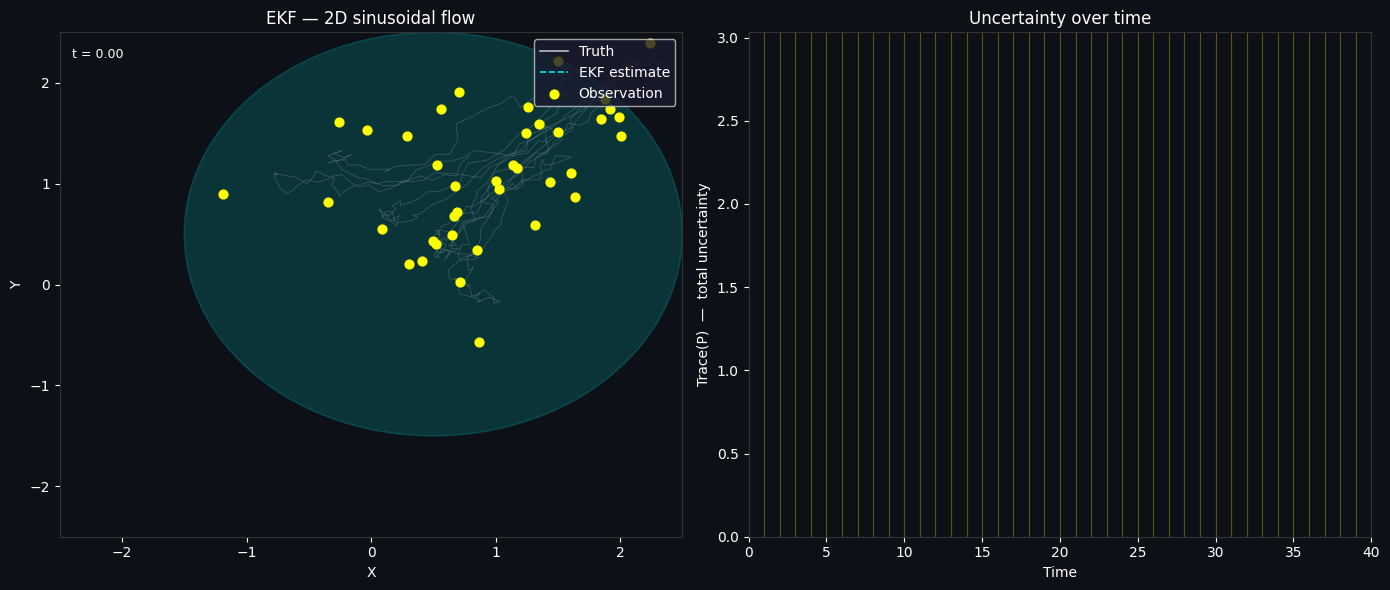

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Ellipse

# ─────────────────────────────────────────────
# TRUE SYSTEM
# ─────────────────────────────────────────────

def true_dynamics(x, t):
    X, Y = x
    return np.array([np.sin(Y) * np.sin(t), np.sin(X) * np.sin(t)])

def simulate_truth(x0, T, dt, sigma_q):
    times = np.arange(0, T, dt)
    xs = [np.array(x0, dtype=float)]
    for i in range(len(times) - 1):
        u = np.random.normal(0, sigma_q, size=2)
        xs.append(xs[-1] + (true_dynamics(xs[-1], dt * i) + u) * dt)
    return np.array(xs), times

# ─────────────────────────────────────────────
# EKF
# ─────────────────────────────────────────────

def jacobian(x_hat, t):
    X, Y = x_hat
    return np.array([[0, np.cos(Y)*np.sin(t)], [np.cos(X)*np.sin(t), 0]])

def ekf_predict(x_hat, P, t, dt, Q):
    F = jacobian(x_hat, t)
    return x_hat + true_dynamics(x_hat, t) * dt, P + (F @ P + P @ F.T + Q) * dt

def ekf_update(x_hat, P, y, R):
    H = np.eye(2)
    S = H @ P @ H.T + R
    K = P @ H.T @ np.linalg.inv(S)
    return x_hat + K @ (y - H @ x_hat), (np.eye(2) - K @ H) @ P

# ─────────────────────────────────────────────
# RUN EKF
# ─────────────────────────────────────────────

np.random.seed(42)
T, dt, sigma_q, sigma_r, obs_every = 40.0, 0.1, 0.5, 0.3, 10
Q = np.eye(2) * sigma_q**2
R = np.eye(2) * sigma_r**2 * 0

x0 = [0.5, 0.5]
truth, times = simulate_truth(x0, T, dt, sigma_q)

x_hat, P = np.array(x0, dtype=float), np.eye(2) * 1.0
estimates, covariances, observations, obs_steps = [x_hat.copy()], [P.copy()], [], []

for i in range(1, len(times)):
    x_hat, P = ekf_predict(x_hat, P, times[i-1], dt, Q)
    if i % obs_every == 0:
        y = truth[i] + np.random.normal(0, sigma_r, size=2)
        observations.append(y)
        obs_steps.append(i)
        x_hat, P = ekf_update(x_hat, P, y, R)
    estimates.append(x_hat.copy())
    covariances.append(P.copy())

estimates = np.array(estimates)

# ─────────────────────────────────────────────
# ANIMATION
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')

ax = axes[0]
ax.set_facecolor('#0d1117')
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_xlabel('X', color='white')
ax.set_ylabel('Y', color='white')
ax.set_title('EKF — 2D sinusoidal flow', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_color('#333')

ax2 = axes[1]
ax2.set_facecolor('#0d1117')
ax2.set_xlabel('Time', color='white')
ax2.set_ylabel('Trace(P)  —  total uncertainty', color='white')
ax2.set_title('Uncertainty over time', color='white')
ax2.set_xlim(0, T)
ax2.set_ylim(0, max(np.trace(c) for c in covariances) * 1.1)
ax2.tick_params(colors='white')
for spine in ax2.spines.values(): spine.set_color('#333')

# Static full truth trajectory (faint)
ax.plot(truth[:, 0], truth[:, 1], color='white', lw=0.5, alpha=0.2)

# Dynamic elements
true_line,  = ax.plot([], [], color='white',  lw=1.2, alpha=0.7, label='Truth')
est_line,   = ax.plot([], [], color='cyan',   lw=1.2, alpha=0.9, ls='--', label='EKF estimate')
obs_scatter = ax.scatter([], [], color='yellow', s=40, zorder=5, label='Observation')
ellipse_patch = Ellipse((0,0), 0, 0, angle=0, alpha=0.15,
                         facecolor='cyan', edgecolor='cyan', lw=1.2)
ax.add_patch(ellipse_patch)
ax.legend(facecolor='#1a1a2e', labelcolor='white', framealpha=0.8, loc='upper right')

trace_line, = ax2.plot([], [], color='cyan', lw=1.5)
obs_vlines = []

time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, color='white', fontsize=9)

def update_ellipse(mean, cov):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * 2.0 * np.sqrt(np.abs(vals))
    ellipse_patch.set_center(mean)
    ellipse_patch.width  = width
    ellipse_patch.height = height
    ellipse_patch.angle  = angle

obs_xs, obs_ys = [], []

def animate(i):
    i = min(i, len(times) - 1)

    true_line.set_data(truth[:i+1, 0], truth[:i+1, 1])
    est_line.set_data(estimates[:i+1, 0], estimates[:i+1, 1])
    update_ellipse(estimates[i], covariances[i])

    if i in obs_steps:
        idx = obs_steps.index(i)
        obs_xs.append(observations[idx][0])
        obs_ys.append(observations[idx][1])
        obs_scatter.set_offsets(np.c_[obs_xs, obs_ys])

        # vertical line on uncertainty plot
        vl = ax2.axvline(times[i], color='yellow', alpha=0.3, lw=0.8)
        obs_vlines.append(vl)

    trace_line.set_data(times[:i+1], [np.trace(covariances[j]) for j in range(i+1)])
    time_text.set_text(f't = {times[i]:.2f}')

    return true_line, est_line, ellipse_patch, obs_scatter, trace_line, time_text

ani = animation.FuncAnimation(
    fig, animate, frames=len(times),
    interval=30, blit=False
)

plt.tight_layout()
ani.save('./output_gif', writer='pillow', fps=30, dpi=100)
print("Saved.")